In [1]:
import torch
import math
from torch import nn
from d2l import torch as d2l

掩蔽softmax操作，任何超出有效长度的位置都将被掩蔽并置为0

In [2]:
def masked_softmax(X, valid_lens):
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)
        X = d2l.sequence_mask(X.reshape(-1,shape[-1]),valid_lens,value=-1e6)
        return nn.functional.softmax(X.reshape(shape), dim=-1)

In [3]:
masked_softmax(torch.rand(2,2,4), torch.tensor([2, 3]))

tensor([[[0.6505, 0.3495, 0.0000, 0.0000],
         [0.4204, 0.5796, 0.0000, 0.0000]],

        [[0.3257, 0.3538, 0.3206, 0.0000],
         [0.3076, 0.2879, 0.4045, 0.0000]]])

In [4]:
masked_softmax(torch.rand(2,2,4), torch.tensor([[1,3], [2,4]]))

tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.3317, 0.4276, 0.2407, 0.0000]],

        [[0.3859, 0.6141, 0.0000, 0.0000],
         [0.2087, 0.3125, 0.2543, 0.2245]]])

加性注意力

In [5]:
class AdditiveAttention(nn.Module):
    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super(AdditiveAttention, self).__init__(**kwargs)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=False)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=False)
        self.w_v = nn.Linear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)
    def forward(self, queries, keys, values, valid_lens):
        queries, keys = self.W_q(queries), self.W_k(keys)
        # 在维度扩展后，queries的形状：（batch_size, 查询的个数,1, num_hidden）
        # key的形状：(batch_size, 1, 键值对的个数， num_hiddens)
        # 使用广播方式求和
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = torch.tanh(features)
        scores = self.w_v(features).squeeze(-1)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)


In [6]:
queries, keys = torch.normal(0, 1, (2, 1, 20)), torch.ones((2, 10, 2))
values = torch.arange(40, dtype=torch.float32).reshape(1, 10, 4).repeat(2, 1, 1)
valid_lens = torch.tensor([2, 6])
attention = AdditiveAttention(key_size=2, query_size=20, num_hiddens=8, dropout=0.1)
attention.eval()
attention(queries, keys, values, valid_lens)

tensor([[[ 2.0000,  3.0000,  4.0000,  5.0000]],

        [[10.0000, 11.0000, 12.0000, 13.0000]]], grad_fn=<BmmBackward0>)

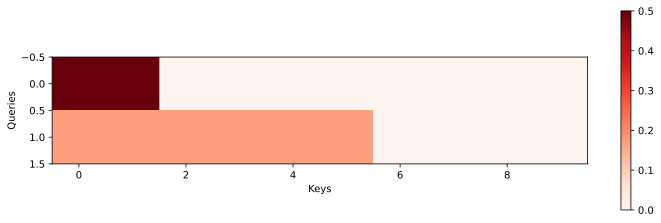

In [7]:
d2l.show_heatmaps(attention.attention_weights.reshape((1,1,2,10)),
                  xlabel='Keys', ylabel='Queries',figsize=(12, 6))

修改修改小例子中的键，并且可视化注意力权重。可加性注意力和缩放的“点－积”注意力是否仍然产生相
同的结果？为什么？

In [ ]:
queries = torch.normal(0, 1, (2, 1, 20))  # 两个查询，维度20
keys1 = torch.normal(0, 0.5, (2, 10, 2))  # 第一个键矩阵，正态分布
keys2 = torch.normal(1, 1, (2, 10, 2))    # 第二个键矩阵，不同的正态分布
values = torch.arange(40, dtype=torch.float32).reshape(1, 10, 4).repeat(2, 1, 1)
valid_lens = torch.tensor([2, 6])
additive_attention = AdditiveAttention(key_size=2, query_size=20, num_hiddens=8, dropout=0.1)
additive_attention.eval()
additive_attention(queries, keys1, values, valid_lens)

tensor([[[ 1.8405,  2.8405,  3.8405,  4.8405]],

        [[10.1108, 11.1108, 12.1108, 13.1108]]], grad_fn=<BmmBackward0>)

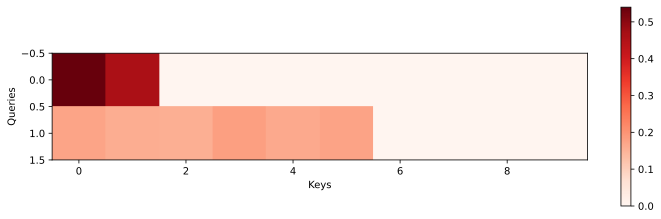

In [10]:
d2l.show_heatmaps(additive_attention.attention_weights.reshape((1,1,2,10)),
                  xlabel='Keys', ylabel='Queries',figsize=(12, 6))

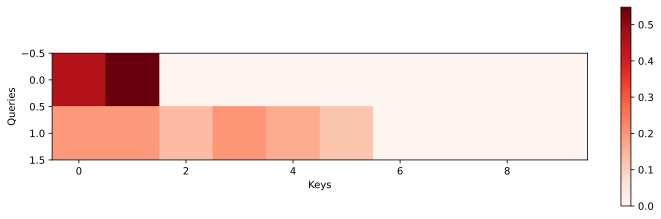

In [12]:
additive_attention(queries, keys2, values, valid_lens)
d2l.show_heatmaps(additive_attention.attention_weights.reshape((1,1,2,10)),
                  xlabel='Keys', ylabel='Queries',figsize=(12, 6))

缩放点积注意力

In [13]:
class DotProductAttention(nn.Module):
    def __init__(self, dropout, **kwargs):
        super(DotProductAttention, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        scores = torch.bmm(queries, keys.transpose(1,2))/math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [14]:
queries = torch.normal(0, 1, (2, 1, 2))
attention = DotProductAttention(dropout=0.5)
attention.eval()
attention(queries, keys, values, valid_lens)

tensor([[[ 2.0000,  3.0000,  4.0000,  5.0000]],

        [[10.0000, 11.0000, 12.0000, 13.0000]]])

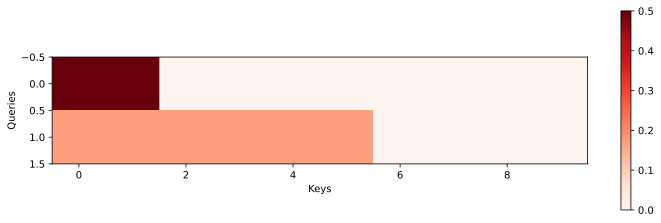

In [15]:
d2l.show_heatmaps(attention.attention_weights.reshape((1,1,2,10)),
                  xlabel='Keys', ylabel='Queries',figsize=(12, 6))

In [16]:
queries = torch.normal(0, 1, (2, 1, 2))
attention = DotProductAttention(dropout=0.5)
attention.eval()
attention(queries, keys1, values, valid_lens)

tensor([[[ 2.3380,  3.3380,  4.3380,  5.3380]],

        [[ 9.6940, 10.6940, 11.6940, 12.6940]]])

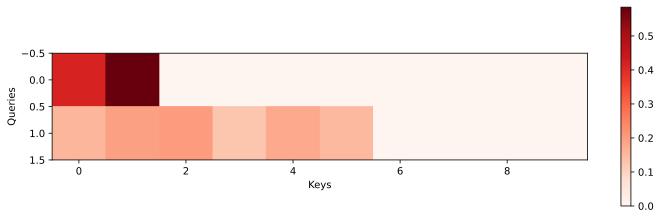

In [17]:
d2l.show_heatmaps(attention.attention_weights.reshape((1,1,2,10)),
                  xlabel='Keys', ylabel='Queries',figsize=(12, 6))

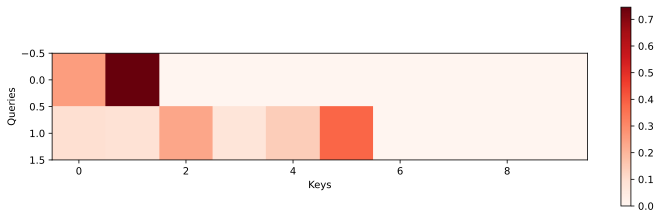

In [19]:
attention(queries, keys2, values, valid_lens)
d2l.show_heatmaps(attention.attention_weights.reshape((1,1,2,10)),
                  xlabel='Keys', ylabel='Queries',figsize=(12, 6))